In [0]:
# Single cell - copy exactly as is
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
from pyspark.sql.functions import col, length

print("Success!")

Success!


In [0]:
storage_account_name = "amazondatalake60306027"
storage_account_key = "YOUR_STORAGE_ACCOUNT_KEY"

spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net", 
    storage_account_key
)


In [0]:
gold_path = f"abfss://curated@{storage_account_name}.dfs.core.windows.net/features_v1/"
df = spark.read.parquet(gold_path)

print(f"Number of rows    : {df.count():,}")
print(f"Number of columns : {len(df.columns)}")

Number of rows    : 845,400,927
Number of columns : 8


In [0]:
df.printSchema()

root
 |-- asin: string (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



In [0]:
from pyspark.sql.types import StringType, FloatType, DoubleType, LongType, IntegerType

required_checks = {
    "reviewText": StringType,
    "asin":       StringType,
    "reviewerID": StringType,
}

numeric_types = (FloatType, DoubleType, LongType, IntegerType)
schema_dict = {f.name: type(f.dataType) for f in df.schema.fields}

for col_name, expected_type in required_checks.items():
    actual = schema_dict.get(col_name, 'MISSING')
    status = 'OK' if actual == expected_type else 'FAIL'
    actual_name = actual.__name__ if actual != 'MISSING' else 'MISSING'
    print(f"[{status}] {col_name}: {actual_name}")


overall_type = schema_dict.get('overall', 'MISSING')
is_numeric = overall_type in [FloatType, DoubleType, LongType, IntegerType]
status = 'OK' if is_numeric else 'FAIL'
overall_name = overall_type.__name__ if overall_type != 'MISSING' else 'MISSING'
print(f"[{status}] overall: {overall_name} (should be numeric)")

[OK] reviewText: StringType
[OK] asin: StringType
[OK] reviewerID: StringType
[OK] overall: DoubleType (should be numeric)


In [0]:
from pyspark.sql.types import StringType
from pyspark.sql.functions import col, count, when

key_cols = ["reviewText", "overall", "asin", "reviewerID"]

string_cols = {
    f.name
    for f in df.schema.fields
    if isinstance(f.dataType, StringType)
}

null_counts = df.select([
    count(
        when(
            col(c).isNull() | (col(c) == "") if c in string_cols else col(c).isNull(),
            c
        )
    ).alias(c)
    for c in key_cols
])

null_counts.show()

+----------+-------+----+----------+
|reviewText|overall|asin|reviewerID|
+----------+-------+----+----------+
|         0|      0|   0|         0|
+----------+-------+----+----------+



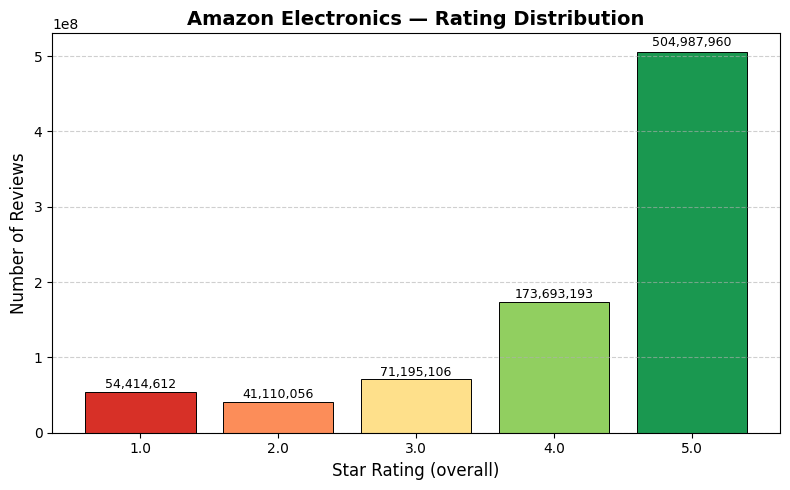

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

rating_counts = (
    df.groupBy("overall")
      .count()
      .orderBy("overall")
      .toPandas()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    rating_counts["overall"].astype(str),
    rating_counts["count"],
    color=["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"],
    edgecolor="black",
    linewidth=0.7,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{bar.get_height():,.0f}",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_xlabel("Star Rating (overall)", fontsize=12)
ax.set_ylabel("Number of Reviews", fontsize=12)
ax.set_title("Amazon Electronics — Rating Distribution", fontsize=14, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

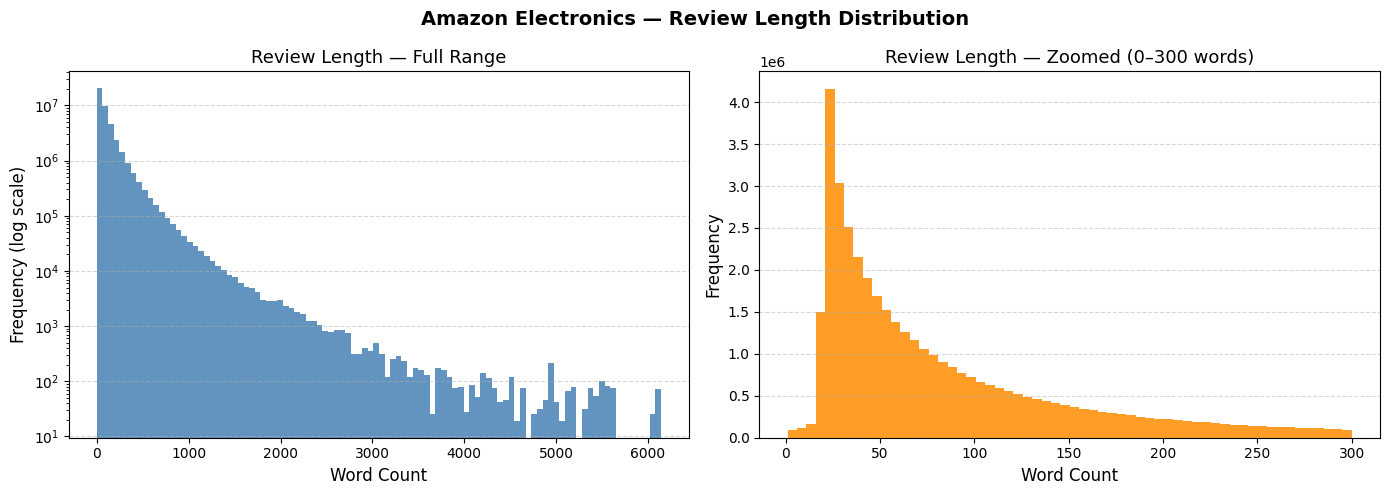

count    4.227668e+07
mean     1.163783e+02
std      1.614439e+02
min      1.000000e+00
25%      3.300000e+01
50%      6.400000e+01
75%      1.340000e+02
max      6.141000e+03
Name: word_count, dtype: float64


In [0]:
from pyspark.sql.functions import size, split

length_pdf = (
    df.withColumn("word_count", size(split("reviewText", r"\s+")))
      .select("word_count")
      .filter(col("word_count") > 0)
      .sample(fraction=0.05, seed=42)   # sample for plotting speed
      .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution (log y-axis)
axes[0].hist(length_pdf["word_count"], bins=100, color="steelblue", edgecolor="none", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_xlabel("Word Count", fontsize=12)
axes[0].set_ylabel("Frequency (log scale)", fontsize=12)
axes[0].set_title("Review Length — Full Range", fontsize=13)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Right: zoomed (0–300 words covers >95% of reviews)
zoomed = length_pdf[length_pdf["word_count"] <= 300]
axes[1].hist(zoomed["word_count"], bins=60, color="darkorange", edgecolor="none", alpha=0.85)
axes[1].set_xlabel("Word Count", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Review Length — Zoomed (0–300 words)", fontsize=13)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Amazon Electronics — Review Length Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(length_pdf["word_count"].describe())

In [0]:
from pyspark.sql.functions import col

sample_n    = 300_000
sample_seed = 42
total_rows  = df.count()
fraction    = sample_n / total_rows

print(f"Total rows   : {total_rows:,}")
print(f"Target sample: {sample_n:,}")
print(f"Fraction     : {fraction:.6f}")

Total rows   : 845,400,927
Target sample: 300,000
Fraction     : 0.000355

Sampled rows: 299,527


In [0]:
# Build per-year fractions dictionary
year_fractions = {
    row["review_year"]: fraction
    for row in df.select("review_year").distinct().collect()
    if row["review_year"] is not None
}

print("Years found:", sorted(year_fractions.keys()))

# Apply stratified sampling
df_sampled = df.sampleBy("review_year", fractions=year_fractions, seed=sample_seed)

print("Sampled rows:", df_sampled.count())

Years found: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Sampled rows: 299527


In [0]:
# Check schema matches original
df_sampled.printSchema()

# Compare rating distribution with original dataset
# Looking for roughly similar distributions, not exact matches
print("=== Full dataset ===")
df.groupBy("overall").count().orderBy("overall").show()

print("=== Sampled dataset ===")
df_sampled.groupBy("overall").count().orderBy("overall").show()

root
 |-- asin: string (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)

=== Full dataset ===
+-------+---------+
|overall|    count|
+-------+---------+
|    1.0| 54414612|
|    2.0| 41110056|
|    3.0| 71195106|
|    4.0|173693193|
|    5.0|504987960|
+-------+---------+

=== Sampled dataset ===
+-------+------+
|overall| count|
+-------+------+
|    1.0| 19361|
|    2.0| 14555|
|    3.0| 25012|
|    4.0| 61364|
|    5.0|179235|
+-------+------+



In [0]:
print(f"Sampled rows    : {df_sampled.count():,}")
print(f"Sampled columns : {len(df_sampled.columns)}")

Sampled rows    : 299,527
Sampled columns : 8


In [0]:
sampled_gold_path = (
    f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
    "features_v1_sampled/"
)

df_sampled.write \
    .mode("overwrite") \
    .parquet(sampled_gold_path)

print(f"Written to: {sampled_gold_path}")

Written to: abfss://curated@amazondatalake60306027.dfs.core.windows.net/features_v1_sampled/


In [0]:
# Read back to confirm the write succeeded
verify_df = spark.read.parquet(sampled_gold_path)

print(f"Rows in features_v1_sampled : {verify_df.count():,}")
print(f"Columns                     : {len(verify_df.columns)}")

Rows in features_v1_sampled : 299,950
Columns                     : 8
